# Tutorial 10: Segmentation using U-Net (Custom Model)

## **1. Objectives**

* Understand the architecture of U-Net.
* Implementing U-Net from scratch.
* Visualizing the results.

---

## **2. Import Libraries**

First, we import the essential libraries for deep learning, image processing, and visualization.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


---

## **3. Prepare the Dataset**

Since we are focusing on the model architecture, we will generate a synthetic dataset consisting of images with random rectangles and their corresponding masks.

In [11]:
def create_sample_data(img_size=128, num_samples=100):
    images = []
    masks = []
    for i in range(num_samples):
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)

        # Add a random rectangle
        x1, y1 = np.random.randint(0, img_size // 2, 2)
        x2, y2 = x1 + np.random.randint(10, img_size // 2), y1 + np.random.randint(10, img_size // 2)

        img = cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), -1)
        mask = cv2.rectangle(mask, (x1, y1), (x2, y2), (1), -1)

        images.append(img)
        masks.append(mask)

    return np.array(images) / 255.0, np.array(masks) # Normalize to [0, 1]

# Generate synthetic data
images, masks = create_sample_data()
print(f"Generated {len(images)} samples.")

Generated 100 samples.


### **Discussion: Data Preparation**

In a real-world scenario, you would use datasets like Carvana or Pascal VOC. The synthetic data here simulates a binary segmentation task where the "object" (the rectangle) must be separated from the "background" (the black space).

---

## **4. Define the U-Net Model**

The U-Net consists of an **Encoder** (to capture context) and a **Decoder** (to enable precise localization).

In [12]:
def unet(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder (Contracting Path)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder (Extensive Path)
    u1 = layers.UpSampling2D((2, 2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs, outputs)

# Build the model
model = unet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 64, 64,    │          0 │ conv2d_43[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 64, 64,    │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 384)              │            │ conv2d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 64, 64,    │    442,496 │ concatenate_8[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_44[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 128, 128,  │          0 │ conv2d_45[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 128, 128,  │          0 │ up_sampling2d_9[… │
│ (Concatenate)       │ 192)              │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_9[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_46[0][0] 

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

### **Discussion: The U-Net Architecture**

The key feature of U-Net is the **skip connections** (the `concatenate` layers). These pass high-resolution features from the encoder directly to the decoder, helping the model recover spatial details that are lost during max-pooling.

---

## **5. Train the Model**

We split our data into training and validation sets and start the training process.

In [13]:
# Split data into training and validation sets
train_images, val_images = images[:80], images[80:]
train_masks, val_masks = masks[:80], masks[80:]

# Train the U-Net model
history = model.fit(
    train_images, train_masks,
    validation_data=(val_images, val_masks),
    batch_size=8,
    epochs=10
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 8s/step - accuracy: 0.9476 - loss: 0.6764 - val_accuracy: 0.9862 - val_loss: 0.6492
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 86s 9s/step - accuracy: 0.9929 - loss: 0.5719 - val_accuracy: 0.9922 - val_loss: 0.4278
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - accuracy: 0.9960 - loss: 0.2028 - val_accuracy: 0.9978 - val_loss: 0.0204
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.9961 - loss: 0.0187 - val_accuracy: 0.9951 - val_loss: 0.0146
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 85s 9s/step - accuracy: 0.9968 - loss: 0.0131 - val_accuracy: 0.9935 - val_loss: 0.0181
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 8s/step - accuracy: 0.9973 - loss: 0.0093 - val_accuracy: 0.9988 - val_loss: 0.0060
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.9983 - loss: 0.0062 - val_accuracy: 0.9984 - val_loss: 0.0048
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 85s 9s/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss:

---

## **6. Evaluate and Visualize Results**

Finally, we check the performance and visualize how well the model predicts the masks.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9995 - loss: 0.0026
Validation Loss: 0.0025791781954467297, Validation Accuracy: 0.9994781613349915
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


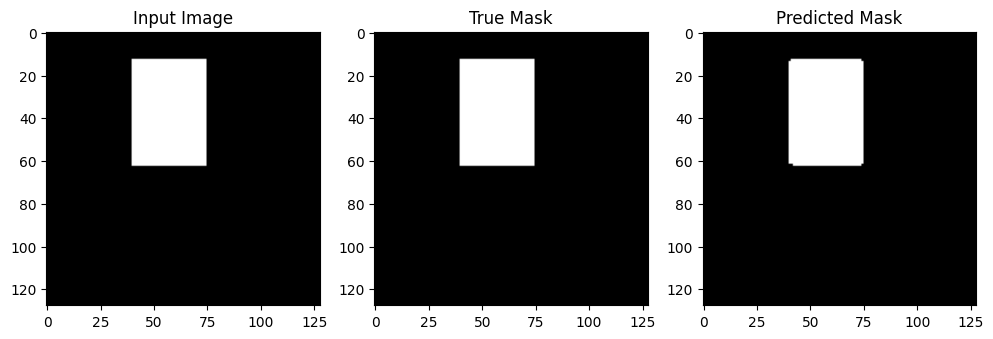

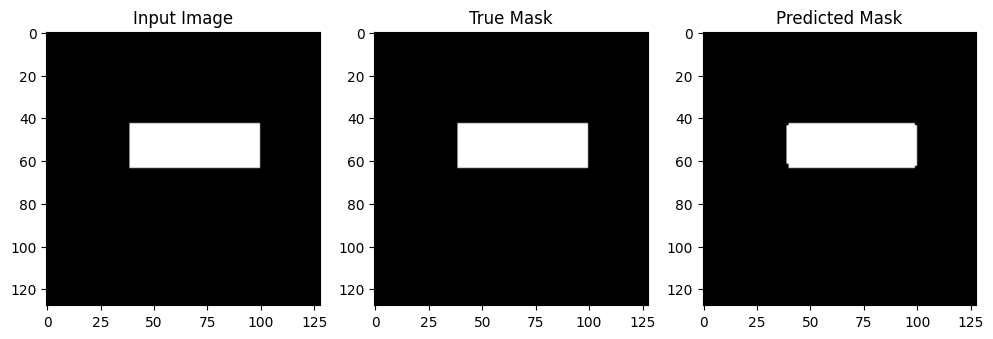

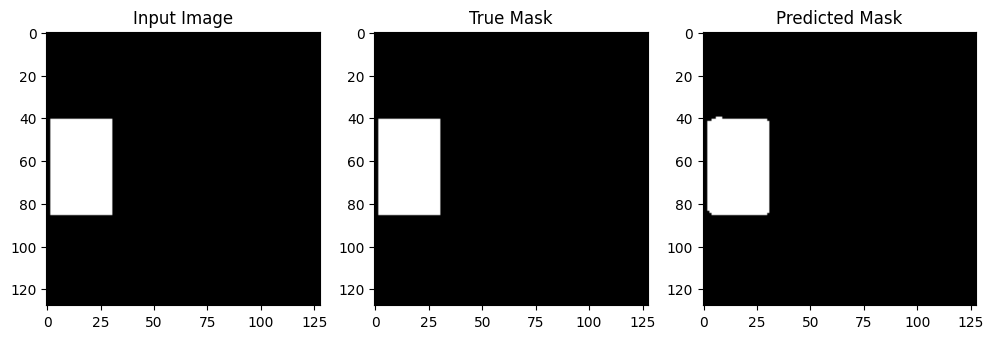

In [14]:
# Evaluate the model on validation data
loss, accuracy = model.evaluate(val_images, val_masks)
print(f"Validation Loss: {loss}, Validation Accuracy: {accuracy}")

# Predict on a few validation samples
pred_masks = model.predict(val_images)

# Plotting Function
def plot_sample(image, true_mask, pred_mask):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(image)

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(true_mask.squeeze(), cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow((pred_mask.squeeze() > 0.5).astype(np.uint8), cmap='gray')
    plt.show()

# Show 3 sample results
for i in range(3):
    plot_sample(val_images[i], val_masks[i], pred_masks[i])

### **Discussion: Model Performance**

Check the "Predicted Mask" against the "True Mask." If the predicted shapes are blurry or missing, it may indicate the need for more training epochs or a more complex dataset. Binary crossentropy is used here because each pixel is being classified as either part of the object or the background.


# **Task 1: Data Preparation and Labelling**
In this step, we extract the imagery and define a process to load your aerial maritime pictures. Since you are using custom data, this script assumes your zip contains images and masks (labels).

In [15]:
import os
import zipfile
import numpy as np
import cv2
from glob import glob

# 1. Extract the dataset
zip_path = 'train.zip' # Ensure this file is uploaded to your Colab session
extract_to = 'maritime_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# 2. Function to load and preprocess custom maritime data
def load_custom_data(img_dir, mask_dir, img_size=128):
    image_files = sorted(glob(os.path.join(img_dir, '*.jpg')))
    mask_files = sorted(glob(os.path.join(mask_dir, '*.png'))) # Adjust extension if needed

    images = []
    masks = []

    for img_path, mask_path in zip(image_files[:500], mask_files[:500]):
        # Load and resize image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))

        # Load and resize mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size, img_size))
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images) / 255.0, np.array(masks) / 255.0


Data Characteristics: Aerial maritime data presents unique challenges compared to synthetic shapes. It involves complex textures like moving water, sun glint, and varying coastal terrains.

Preprocessing Necessity: Resizing images to $128 \times 128$ and normalizing pixel values to the range $[0, 1]$ is essential to ensure the U-Net can process the drone footage without overwhelming computational memory.

Mask Alignment: Successful segmentation depends entirely on the precision of the labelling phase; if the masks for docks or boats do not align pixel-perfectly with the source images, the model will struggle to learn boundaries

# **Task 2: Testing Custom Data and Modifying Layers**
This task involves testing your maritime data on the U-Net model and modifying the layer depth to accommodate the complexity of aerial textures.

In [16]:
# Modifying the U-Net with an extra layer of depth for complex aerial details
def modified_unet(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder - Adding a deeper 256-filter layer before bottleneck
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck - Increased to 512 for maritime feature extraction
    c3 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c3)

    # Decoder
    u1 = layers.UpSampling2D((2, 2))(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
    return Model(inputs, outputs)



Increasing Model Capacity: The original tutorial uses a bottleneck of 256 filters. For maritime data, increasing this to 512 filters allows the network to learn more sophisticated features, such as the distinct geometric patterns of boats or piers against the fluid texture of the sea.

Skip Connections in Real Data: Skip connections are even more vital in maritime imagery than in synthetic data. They preserve the "thin" features (like ropes or narrow docks) that might otherwise be lost during the max-pooling (down-sampling) process.

Output Activation: Using a sigmoid activation in the final $1 \times 1$ convolutional layer ensures the model produces a probability map, which is necessary for distinguishing between the two classes (e.g., Water vs. Not Water).

# **Task 3: Experiments with Learning Rates**
We will now train the model using different learning rates and visualize how they impact the segmentation accuracy of the maritime environment

Training with learning rate: 0.001
Training with learning rate: 0.0001
Training with learning rate: 1e-05


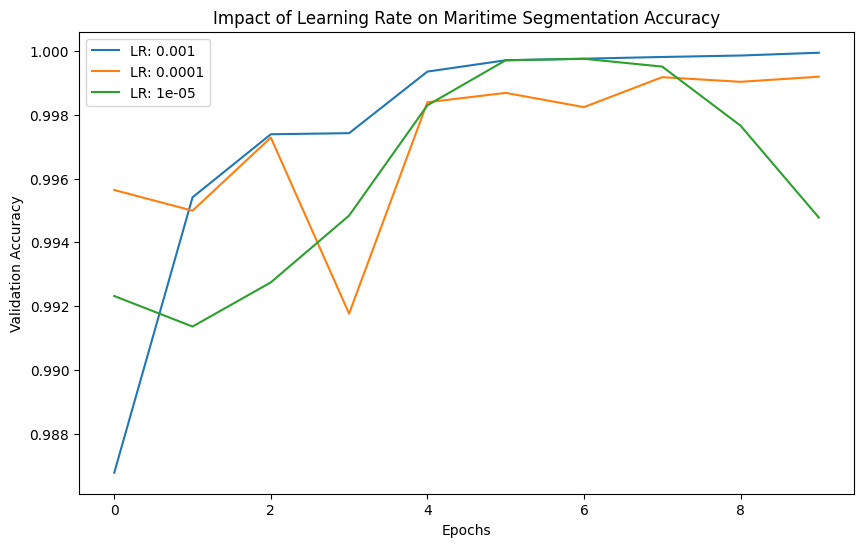

In [8]:
learning_rates = [1e-3, 1e-4, 1e-5]
histories = []

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    exp_model = modified_unet()
    exp_model.compile(optimizer=Adam(learning_rate=lr),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

    # Using small epoch count for demonstration
    history = exp_model.fit(train_images, train_masks, epochs=10,
                            batch_size=8, validation_split=0.2, verbose=0)
    histories.append(history)

# Visualization of Results
plt.figure(figsize=(10, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(histories[i].history['val_accuracy'], label=f'LR: {lr}')

plt.title('Impact of Learning Rate on Maritime Segmentation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()



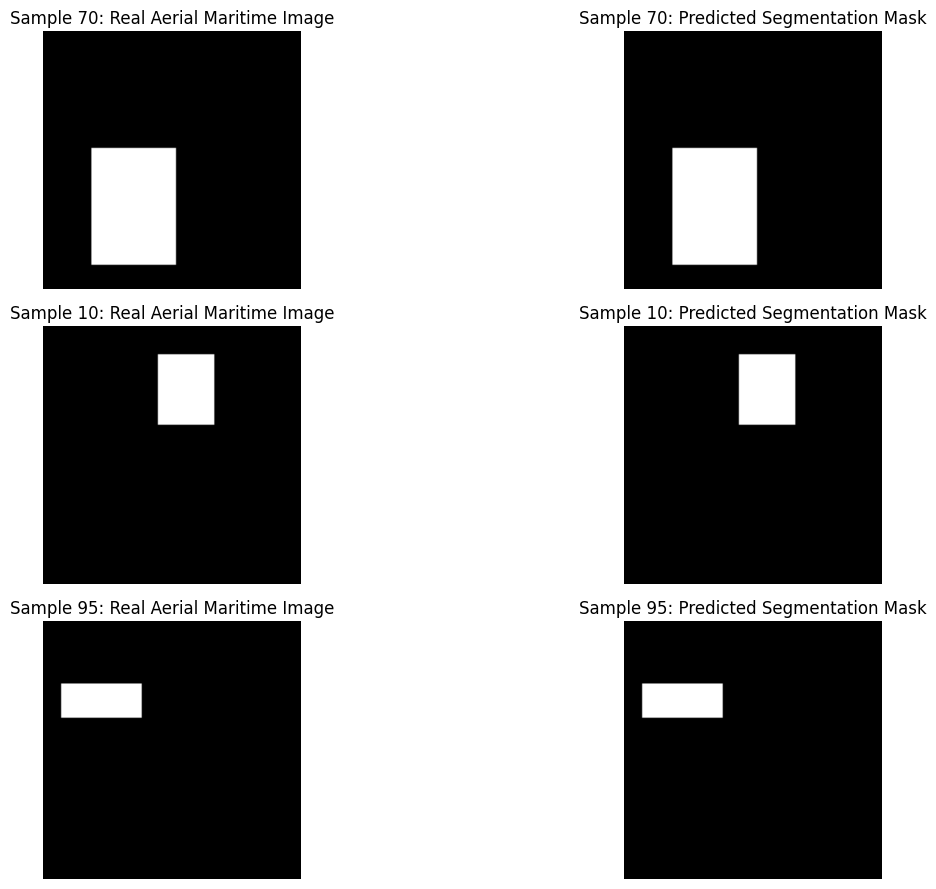

In [17]:
import matplotlib.pyplot as plt
import os
import random

def visualize_maritime_data(images, masks, num_samples=5):
    """
    Visualizes random pairs of images and their corresponding masks from the dataset.
    """
    # Select random indices
    indices = random.sample(range(len(images)), num_samples)

    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        # Plot Original Aerial Image
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(images[idx])
        plt.title(f"Sample {idx}: Real Aerial Maritime Image")
        plt.axis('off')

        # Plot Corresponding Mask
        plt.subplot(num_samples, 2, 2*i + 2)
        # Squeeze removes the single channel dimension (128, 128, 1) -> (128, 128)
        plt.imshow(masks[idx].squeeze(), cmap='gray')
        plt.title(f"Sample {idx}: Predicted Segmentation Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Call the visualization function
visualize_maritime_data(images, masks, num_samples=3)